## Imports


In [1]:
from Pose_Functions import *
import matplotlib.pyplot as plt
import mediapipe as mp
import cv2
import json

## Storing the nodes of the video

In [2]:
video_path = "../../EnisProject/data/test_squat.mp4"
model_path = "data/pose_landmarker.task"
save_path = "data/test_nodes.json"

data_to_json(video_path, save_path, model_path)


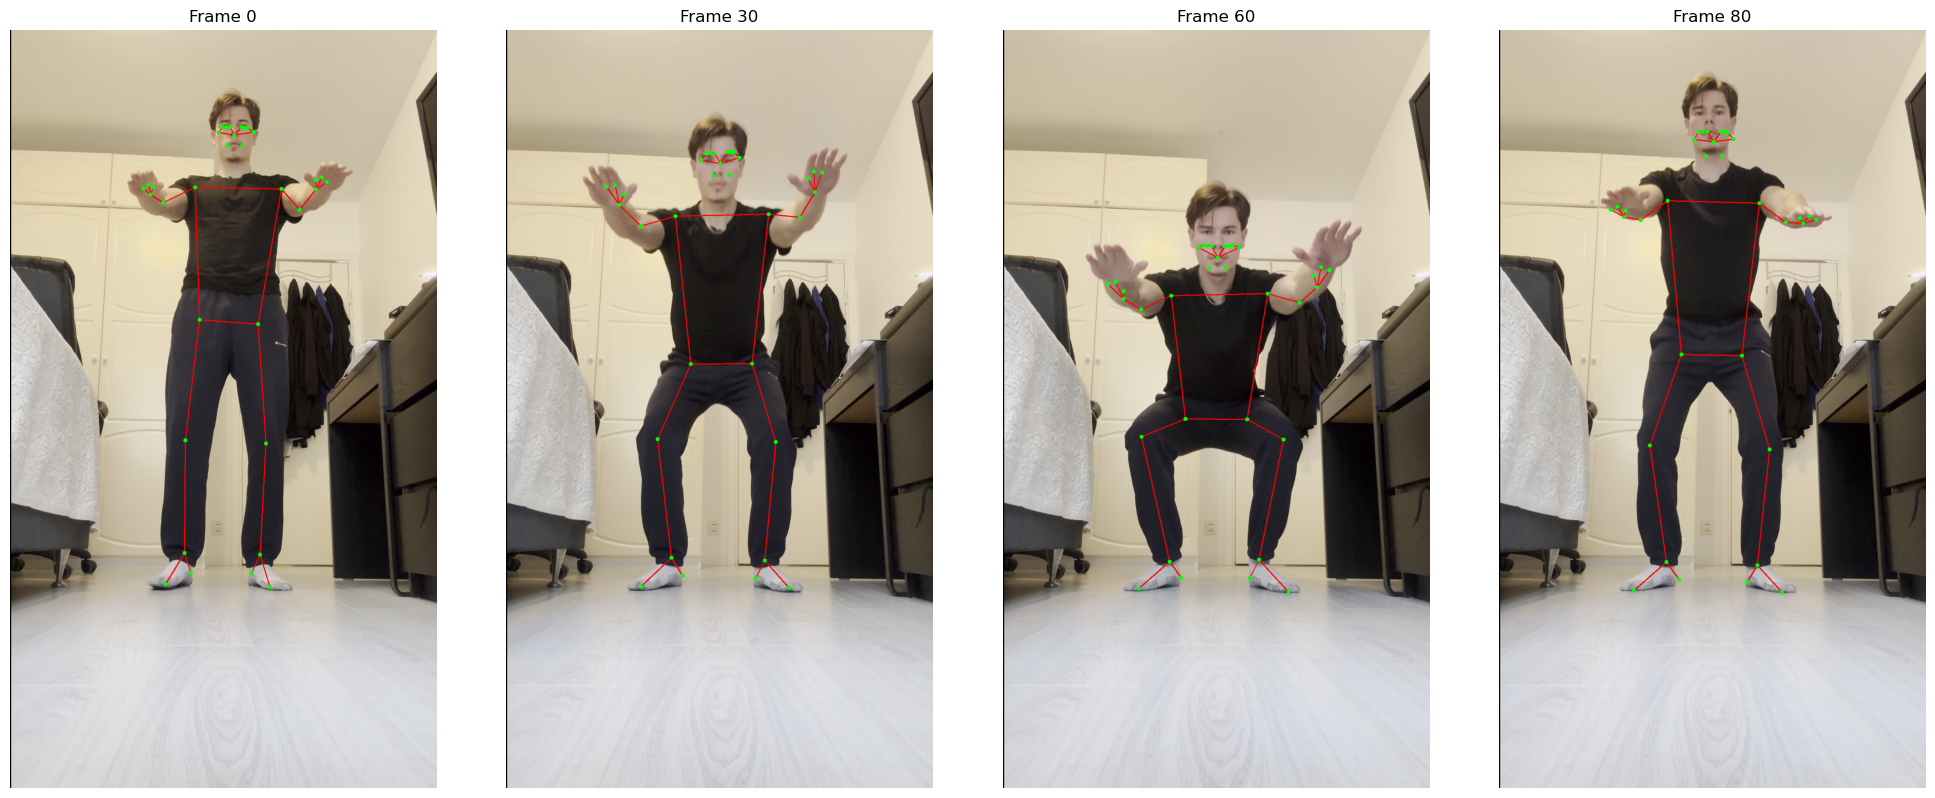

In [4]:
# Load the pose data
with open(save_path, 'r') as f:
    pose_data = json.load(f)

# Load the video
video_path = "../../EnisProject/data/test_squat.mp4"
cap = cv2.VideoCapture(video_path)

# Plot a few frames with landmarks
frame_indices = [0, 30, 60, 80]

fig, axes = plt.subplots(1, len(frame_indices), figsize=(20, 8))

# Define all MediaPipe pose connections
POSE_CONNECTIONS = [
    ("NOSE", "LEFT_EYE_INNER"), ("LEFT_EYE_INNER", "LEFT_EYE"),
    ("LEFT_EYE", "LEFT_EYE_OUTER"), ("NOSE", "RIGHT_EYE_INNER"),
    ("RIGHT_EYE_INNER", "RIGHT_EYE"), ("RIGHT_EYE", "RIGHT_EYE_OUTER"),
    ("NOSE", "LEFT_EAR"), ("NOSE", "RIGHT_EAR"),
    ("LEFT_EYE_OUTER", "LEFT_EAR"), ("RIGHT_EYE_OUTER", "RIGHT_EAR"),
    ("LEFT_MOUTH_CORNER", "RIGHT_MOUTH_CORNER"),
    ("LEFT_SHOULDER", "RIGHT_SHOULDER"),
    ("LEFT_SHOULDER", "LEFT_ELBOW"), ("LEFT_ELBOW", "LEFT_WRIST"),
    ("LEFT_WRIST", "LEFT_PINKY"), ("LEFT_WRIST", "LEFT_INDEX"),
    ("LEFT_WRIST", "LEFT_THUMB"), ("LEFT_PINKY", "LEFT_RING"),
    ("LEFT_INDEX", "LEFT_MIDDLE"), ("LEFT_MIDDLE", "LEFT_RING"),
    ("RIGHT_SHOULDER", "RIGHT_ELBOW"), ("RIGHT_ELBOW", "RIGHT_WRIST"),
    ("RIGHT_WRIST", "RIGHT_PINKY"), ("RIGHT_WRIST", "RIGHT_INDEX"),
    ("RIGHT_WRIST", "RIGHT_THUMB"), ("RIGHT_PINKY", "RIGHT_RING"),
    ("RIGHT_INDEX", "RIGHT_MIDDLE"), ("RIGHT_MIDDLE", "RIGHT_RING"),
    ("LEFT_SHOULDER", "LEFT_HIP"), ("RIGHT_SHOULDER", "RIGHT_HIP"),
    ("LEFT_HIP", "RIGHT_HIP"),
    ("LEFT_HIP", "LEFT_KNEE"), ("LEFT_KNEE", "LEFT_ANKLE"),
    ("LEFT_ANKLE", "LEFT_HEEL"), ("LEFT_ANKLE", "LEFT_FOOT_INDEX"),
    ("RIGHT_HIP", "RIGHT_KNEE"), ("RIGHT_KNEE", "RIGHT_ANKLE"),
    ("RIGHT_ANKLE", "RIGHT_HEEL"), ("RIGHT_ANKLE", "RIGHT_FOOT_INDEX")
]

for idx, frame_num in enumerate(frame_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        h, w = frame_rgb.shape[:2]
        
        # Draw landmarks
        if frame_num < len(pose_data['frames']):
            joints = pose_data['frames'][frame_num]['joints']
            
            # Draw connections first (so they appear behind landmarks)
            for joint1, joint2 in POSE_CONNECTIONS:
                if joint1 in joints and joint2 in joints:
                    x1 = int(joints[joint1]['x'] * w)
                    y1 = int(joints[joint1]['y'] * h)
                    x2 = int(joints[joint2]['x'] * w)
                    y2 = int(joints[joint2]['y'] * h)
                    cv2.line(frame_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
            
            # Draw landmarks on top
            for joint_name, coords in joints.items():
                x = int(coords['x'] * w)
                y = int(coords['y'] * h)
                cv2.circle(frame_rgb, (x, y), 5, (0, 255, 0), -1)
        
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(f"Frame {frame_num}")
        axes[idx].axis('off')

cap.release()
plt.tight_layout()
plt.show()